In [1]:
import json
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import StandardScaler

with open('cresci-stock-2018_tweets.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# etykiety
labels_df = pd.read_csv(
    'cresci-stock-2018.tsv',
    sep='\t',
    header=None,
    names=['id', 'label']
)

label_map = {'human': 0, 'bot': 1}
labels_df['target'] = labels_df['label'].map(label_map)

# ekstrakcja danych o użytkowniku
def extract_user_data(record):
    user_info = record['user']
    return user_info

user_data_list = [extract_user_data(record) for record in raw_data]
df_users = pd.DataFrame(user_data_list)

df_users['id'] = df_users['id'].astype(str)
labels_df['id'] = labels_df['id'].astype(str)
df_merged = df_users.merge(labels_df[['id', 'target']], on='id')



In [2]:
df_users['id'].nunique()

13276

używam rozszerzenia Data Wrangler do przejrzenia dataframe'a w wygodnej formie, sceenshoty są w plikach image.png i image1.png.
Na podstawie podsumowań każdej kolumny od razu wybieram zmienne do usunięcia, które mają za mało distinct wartości (za mala zmienność) albo nie mają sensu do uzycia do ML - np kolumny z ID.

* do usuniecia po obejrzeniu danych:
* id,
* id_str,
* name,
* screen_name,
* entities (dubluje informacje z kolumny url),
* protected (0 zmiennosci, 100% danych ma False),
* utc_offset (100% missing),
* time_zone (100% missing),
* verified (99% False),
* contributors_enabled (100% false),
* is_translator (100% False),
* is_translation_enabled (99% False),
* profile_image_url,
* profile_image_url_https,
* default_profile_image (99% false),
* following (100% false),
* follow_request_sent (100% false),
* notifications (100% false),
* translator_type (99% none)


In [3]:
columns_to_drop = [
    'id',
    'id_str',
    'name',
    'screen_name',
    'entities',
    'protected',
    'utc_offset',
    'time_zone',
    'verified',
    'contributors_enabled',
    'is_translator',
    'is_translation_enabled',
    'profile_image_url',
    'profile_image_url_https',
    'profile_background_image_url_https',
    'default_profile_image',
    'following',
    'follow_request_sent',
    'notifications',
    'translator_type'
]

df_cleaned = df_merged.drop(columns=columns_to_drop, errors='ignore')


In [4]:
#Tworzenie deterministycznych cech - wartosci wynikaja bezposrednio z pojedynczej obserwacji, nie ma porownan do rozkladu calego datasetu
df_cleaned['has_description'] = df_cleaned['description'].astype(bool).astype(int)

df_cleaned['has_location'] = df_cleaned['location'].str.strip().apply(lambda x: 0 if x == '' else 1)

df_cleaned['has_default_bg_theme'] = df_cleaned['profile_background_image_url'].apply(
    lambda x: 0 if 'theme1/bg.png' in str(x) else 1)

df_cleaned['geo_enabled'] = df_cleaned['geo_enabled'].astype(int)

df_cleaned['profile_background_tile'] = df_cleaned['profile_background_tile'].astype(int)

df_cleaned['profile_use_background_image'] = df_cleaned['profile_use_background_image'].astype(int)

df_cleaned['default_profile'] = df_cleaned['default_profile'].astype(int)

df_cleaned['has_extended_profile'] = df_cleaned['has_extended_profile'].astype(int)

df_cleaned['has_added_url'] = df_cleaned['url'].apply(lambda x: 1 if pd.notna(x) and str(x).strip() != '' else 0)
df_cleaned['has_profile_banner'] = df_merged['profile_banner_url'].notnull().astype(int)

df_cleaned['user_created_at'] = pd.to_datetime(df_cleaned['created_at'],errors='coerce').dt.tz_localize(None)
df_cleaned['account_age_days'] = (pd.Timestamp('2017-09-30') - df_cleaned['user_created_at']).dt.days

C:\Users\julia\AppData\Local\Temp\ipykernel_36444\444091878.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cleaned['user_created_at'] = pd.to_datetime(df_cleaned['created_at'],errors='coerce').dt.tz_localize(None)


In [5]:
print(df_cleaned['target'].value_counts())

target
1    7102
0    6174
Name: count, dtype: int64


In [6]:
#train test split - moje klasy są już zbalansowane (47%/53% więc nie robiłam downsamplingu ani oversamplingu)
X = df_cleaned.drop(columns=['target'])
y = df_cleaned['target']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

In [7]:
#Po splicie tylko bazujac na statystykach z train setu robie pozostale cechy:

# Wyznaczenie najczęstszych kategorii wyłącznie na train secie

top_profile_text_colors = X_train['profile_text_color'].value_counts().nlargest(2).index.tolist()

top_sidebar_colors = X_train['profile_sidebar_fill_color'].value_counts().nlargest(3).index.tolist()

top_sidebar_border_colors = X_train['profile_sidebar_border_color'].value_counts().nlargest(3).index.tolist()

top_profile_link_colors = X_train['profile_link_color'].value_counts().nlargest(2).index.tolist()

top_profile_background_colors = X_train['profile_background_color'].value_counts().nlargest(3).index.tolist()

top_lang = X_train['lang'].value_counts().nlargest(3).index.tolist()


#utworzenie cech osobno na train i test secie

X_train['profile_text_color_cat'] = X_train['profile_text_color'].apply(
    lambda x: x if x in top_profile_text_colors else 'other'
)

X_train['sidebar_fill_color_cat'] = X_train['profile_sidebar_fill_color'].apply(
    lambda x: x if x in top_sidebar_colors else 'other'
)

X_train['sidebar_border_color_cat'] = X_train['profile_sidebar_border_color'].apply(
    lambda x: x if x in top_sidebar_border_colors else 'other'
)

X_train['profile_link_color_cat'] = X_train['profile_link_color'].apply(
    lambda x: x if x in top_profile_link_colors else 'other'
)

X_train['profile_background_color_cat'] = X_train['profile_background_color'].apply(
    lambda x: x if x in top_profile_background_colors else 'other'
)

X_train['lang_cat'] = X_train['lang'].apply(
    lambda x: x if x in top_lang else 'other'
)


#test set
X_test['profile_text_color_cat'] = X_test['profile_text_color'].apply(
    lambda x: x if x in top_profile_text_colors else 'other'
)

X_test['sidebar_fill_color_cat'] = X_test['profile_sidebar_fill_color'].apply(
    lambda x: x if x in top_sidebar_colors else 'other'
)

X_test['sidebar_border_color_cat'] = X_test['profile_sidebar_border_color'].apply(
    lambda x: x if x in top_sidebar_border_colors else 'other'
)

X_test['profile_link_color_cat'] = X_test['profile_link_color'].apply(
    lambda x: x if x in top_profile_link_colors else 'other'
)

X_test['profile_background_color_cat'] = X_test['profile_background_color'].apply(
    lambda x: x if x in top_profile_background_colors else 'other'
)

X_test['lang_cat'] = X_test['lang'].apply(
    lambda x: x if x in top_lang else 'other'
)


In [8]:
#Eksperymentuję z feature engineeringiem:
X_train['followers_friends_ratio'] = X_train['followers_count'] / (X_train['friends_count'] + 1)

X_train['tweets_per_day'] = X_train['statuses_count'] / (X_train['account_age_days'] + 1)

X_train['favourites_per_day'] = X_train['favourites_count'] / (X_train['account_age_days'] + 1)

In [9]:
# Feature engineering - zbiór testowy
X_test['followers_friends_ratio'] = (
X_test['followers_count'] / (X_test['friends_count'] + 1)
)

X_test['tweets_per_day'] = (
    X_test['statuses_count'] / (X_test['account_age_days'] + 1)
)

X_test['favourites_per_day'] = (
    X_test['favourites_count'] / (X_test['account_age_days'] + 1)
)

In [10]:
#drop kolumn z których byly robione zmienne
columns_to_drop_2 = [
    'description',
    'user_created_at',
    'created_at',
    'location',
    'url' ,
    'lang',
    'profile_background_image_url',
    'profile_banner_url',
    'profile_text_color',
    'profile_sidebar_fill_color',
    'profile_sidebar_border_color',
    'profile_link_color',
    'profile_background_color' ]

X_train = X_train.drop(columns=columns_to_drop_2)
X_test = X_test.drop(columns=columns_to_drop_2)

In [11]:



'''ogladam tak wyczyszczony dataset w Data Wrangler: image2.png i image3.png
generuję raport o statystykach każdej zmiennej i korelajach z biblioteki ydata-profiling.
Nie uruchamiam tu kodu do generowania, ponieważ biblioteka nie obsługuje Pythona 3.14 którego mam lokalnie,
więc wygenerowałam raport w Google Colab. Jest załączony jako plik html.

Kod do wygenerowania raportu:

!pip install ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(
    X_train,
    explorative=False,
    minimal=True,
    correlations={
        "pearson": {"calculate": True},
        "spearman": {"calculate": False},
        "kendall": {"calculate": False},
        "phi_k": {"calculate": True},
        "cramers": {"calculate": True}
    },
    vars={"num": {"low_categorical_threshold": 0}}
)

profile.to_file("korelacje_male.html")

from google.colab import files
files.download("korelacje_male.html")'''



'ogladam tak wyczyszczony dataset w Data Wrangler: image2.png i image3.png\ngeneruję raport o statystykach każdej zmiennej i korelajach z biblioteki ydata-profiling.\nNie uruchamiam tu kodu do generowania, ponieważ biblioteka nie obsługuje Pythona 3.14 którego mam lokalnie,\nwięc wygenerowałam raport w Google Colab. Jest załączony jako plik html.\n\nKod do wygenerowania raportu:\n\n!pip install ydata-profiling\nfrom ydata_profiling import ProfileReport\n\nprofile = ProfileReport(\n    X_train,\n    explorative=False,\n    minimal=True,\n    correlations={\n        "pearson": {"calculate": True},\n        "spearman": {"calculate": False},\n        "kendall": {"calculate": False},\n        "phi_k": {"calculate": True},\n        "cramers": {"calculate": True}\n    },\n    vars={"num": {"low_categorical_threshold": 0}}\n)\n\nprofile.to_file("korelacje_male.html")\n\nfrom google.colab import files\nfiles.download("korelacje_male.html")'

Ponieważ mam różne typy zmiennych i interesuje mnie różny rodzaj korelacji (nie tylko liniowa) oglądam macierz i tabelę statystyki Phik. Większość zmiennych nie jest skorelowana, ale widać mocne korelacje przy zmiennych kategorycznych kolorów profilu. Bardzo wysoka wartość Phik dla par tych zmiennych i zmiennej "default profile". Usunę zmienne mówiące o kolorach elementow profilu, a zostawię zmienną default profile, bo jest najbardziej ogólna.

In [12]:
columns_to_drop = [
    'listed_count',
    'profile_text_color_cat',
    'sidebar_fill_color_cat',
    'sidebar_border_color_cat',
    'profile_link_color_cat',
    'profile_background_color_cat'
]

X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

count    10620.000000
mean      1789.982298
std        977.090252
min         25.000000
25%        972.750000
50%       1995.000000
75%       2556.250000
max       4104.000000
Name: account_age_days, dtype: float64


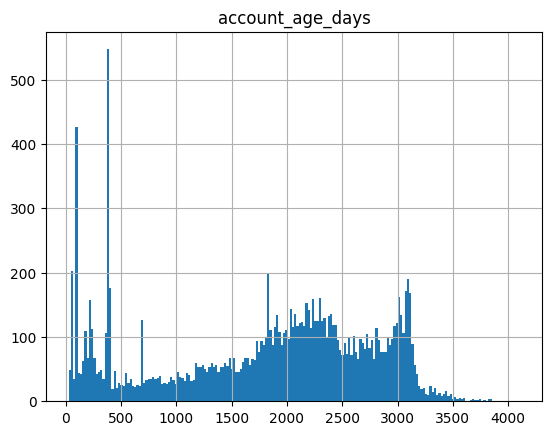

count    1.062000e+04
mean     1.757760e+03
std      4.493285e+04
min      0.000000e+00
25%      1.000000e+01
50%      4.000000e+01
75%      2.410000e+02
max      3.787842e+06
Name: followers_count, dtype: float64


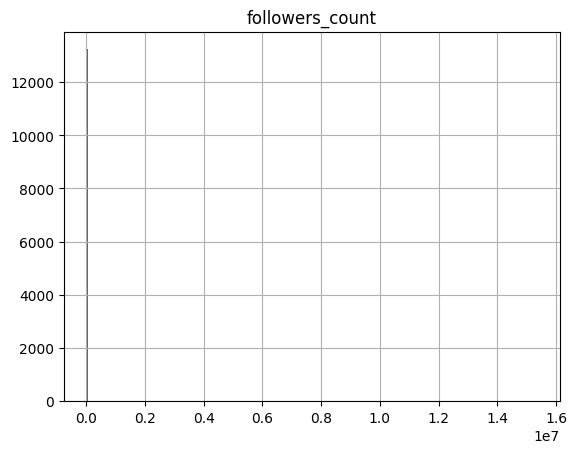

count     10620.000000
mean        394.032392
std        2427.584732
min           0.000000
25%           0.000000
50%          53.500000
75%         306.000000
max      148095.000000
Name: friends_count, dtype: float64


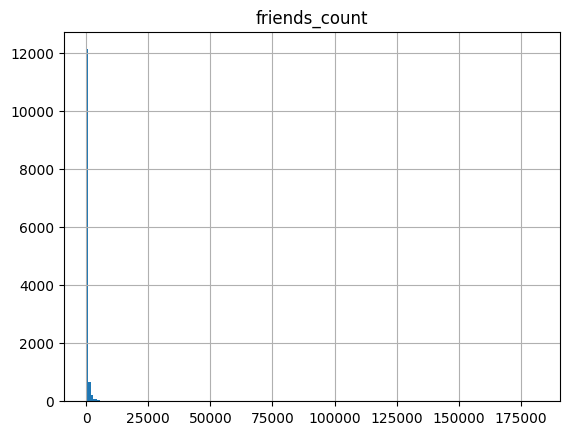

count    1.062000e+04
mean     1.015911e+04
std      4.766886e+04
min      4.000000e+00
25%      1.013000e+03
50%      2.527500e+03
75%      4.871500e+03
max      2.362464e+06
Name: statuses_count, dtype: float64


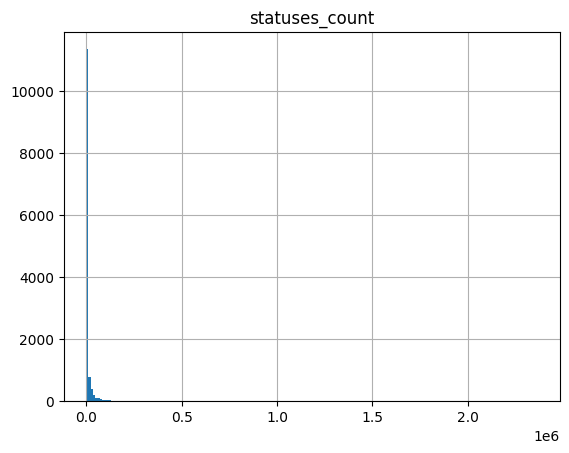

count     10620.000000
mean       5847.129379
std       18931.797787
min           0.000000
25%         562.000000
50%        1631.500000
75%        2595.000000
max      572806.000000
Name: favourites_count, dtype: float64


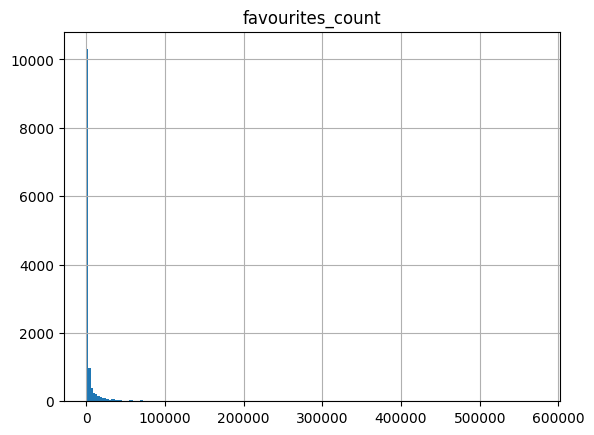

In [ ]:
'''import seaborn as sns
import matplotlib.pyplot as plt

for col in ['account_age_days', 'followers_count', 'friends_count', 'statuses_count', 'favourites_count']:
    print(X_train[col].describe())
    plt.title(col)
    df_cleaned[col].hist(bins=200)
    plt.show()

'''

In [14]:
print(X_train.columns.tolist())

['followers_count', 'friends_count', 'favourites_count', 'geo_enabled', 'statuses_count', 'profile_background_tile', 'profile_use_background_image', 'has_extended_profile', 'default_profile', 'has_description', 'has_location', 'has_default_bg_theme', 'has_added_url', 'has_profile_banner', 'account_age_days', 'lang_cat', 'followers_friends_ratio', 'tweets_per_day', 'favourites_per_day']


problem long tails, ale modele drzewiaste powinny sobie poradzic. Nie wykonuję na razie również np standaryzacji, bo skupiam się na modelach drzewiastych.

In [15]:
#OHE na zmienej kategorialnej lang_cat - wcześniej mniejsze kategorie wrzuciłam do 'other'
from sklearn.preprocessing import OneHotEncoder

# Inicjalizacja kodera
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Dopasowanie kodera do zbioru treningowego i transformacja
X_train_encoded = encoder.fit_transform(X_train[['lang_cat']])

# Transformacja zbioru testowego przy użyciu kodera dopasowanego do train
X_test_encoded = encoder.transform(X_test[['lang_cat']])

# Pobranie nazw utworzonych kolumn
encoded_columns = encoder.get_feature_names_out(['lang_cat'])

# Konwersja do DataFrame
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns,
    index=X_test.index
)

# Usunięcie oryginalnej zmiennej kategorycznej
X_train = X_train.drop(columns=['lang_cat'])
X_test = X_test.drop(columns=['lang_cat'])

# Połączenie zmiennych numerycznych i zakodowanej zmiennej lang_cat
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from scipy.stats import randint, uniform, loguniform

In [17]:
baseline_models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )
}

In [19]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

baseline_results = []

for name, model in baseline_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1',
            'roc_auc': 'roc_auc'
        },
        n_jobs=-1
    )

    baseline_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC AUC': scores['test_roc_auc'].mean()
    })

baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df)


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Decision Tree,0.824482,0.836177,0.835768,0.835884,0.823635
1,Random Forest,0.872222,0.881808,0.879072,0.880370,0.942467
2,XGBoost,0.873446,0.883488,0.879424,0.881408,0.943908


In [20]:
dt_params = {
    'max_depth': randint(3, 31),
    'min_samples_split': randint(2, 41),
    'min_samples_leaf': randint(1, 21),
    'max_features': ['sqrt', 'log2', None]
}

rf_params = {
    'n_estimators': randint(100, 501),
    'max_depth': randint(5, 41),
    'min_samples_leaf': randint(1, 11),
    'max_features': ['sqrt', 'log2', None]
}

xgb_params = {
    'n_estimators': randint(100, 501),
    'max_depth': randint(3, 11),
    'learning_rate': loguniform(0.01, 0.2),
    'min_child_weight': randint(1, 11),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': loguniform(1e-4, 1),
    'reg_lambda': loguniform(0.1, 10)
}

In [21]:


searches = {
    "Decision Tree": RandomizedSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_distributions=dt_params,
        n_iter=100,
        scoring={
            'roc_auc': 'roc_auc',
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1'
        },
        refit='roc_auc',
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1,
        return_train_score=True
    ),

    "Random Forest": RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_distributions=rf_params,
        n_iter=100,
        scoring={
            'roc_auc': 'roc_auc',
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1'
        },
        refit='roc_auc',
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1,
        return_train_score=True
    ),

    "XGBoost": RandomizedSearchCV(
        estimator=XGBClassifier(
            eval_metric='logloss',
            random_state=42
        ),
        param_distributions=xgb_params,
        n_iter=100,
        scoring={
            'roc_auc': 'roc_auc',
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1'
        },
        refit='roc_auc',
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1,
        return_train_score=True
    )
}

In [22]:
best_models = {}
tuned_results = []

for name, search in searches.items():

    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    search.fit(X_train, y_train)

    # najlepszy model wybrany na podstawie CV ROC AUC
    best_models[name] = search.best_estimator_

    # indeks najlepszej konfiguracji
    best_index = search.best_index_

    print("Best parameters:")
    print(search.best_params_)

    print("\nBest CV results:")

    tuned_results.append({
        'Model': name,
        'Accuracy': search.cv_results_['mean_test_accuracy'][best_index],
        'Precision': search.cv_results_['mean_test_precision'][best_index],
        'Recall': search.cv_results_['mean_test_recall'][best_index],
        'F1': search.cv_results_['mean_test_f1'][best_index],
        'ROC AUC': search.cv_results_['mean_test_roc_auc'][best_index]
    })

tuned_results_df = pd.DataFrame(tuned_results)

display(tuned_results_df)


Decision Tree
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters:
{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 9, 'min_samples_split': 38}

Best CV results:

Random Forest
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters:
{'max_depth': 24, 'max_features': None, 'min_samples_leaf': 3, 'n_estimators': 500}

Best CV results:

XGBoost
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters:
{'colsample_bytree': np.float64(0.7540390914407701), 'gamma': np.float64(0.42556833575842845), 'learning_rate': np.float64(0.025841935310839222), 'max_depth': 10, 'min_child_weight': 2, 'n_estimators': 380, 'reg_alpha': np.float64(0.003791105473537743), 'reg_lambda': np.float64(4.8800725828931935), 'subsample': np.float64(0.9720067339243328)}

Best CV results:


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Decision Tree,0.848493,0.857327,0.859885,0.858580,0.919072
1,Random Forest,0.874388,0.885467,0.878896,0.882126,0.945020
2,XGBoost,0.877966,0.886893,0.884705,0.885744,0.947380


najlepszy n_estimators w RF jest na granicy przedziału (500), więc dodatkowo sprawdzam robiąc 5-fold CV wyższe wartości tego hiperparaametru

In [26]:
n_estimators_values = [600, 700, 800, 900, 1000]

rf_base_params = {
    'max_depth': 24,
    'max_features': None,
    'min_samples_leaf': 3,
    'random_state': 42
}

rf_n_estimators_results = []

for n in n_estimators_values:
    model = RandomForestClassifier(
        n_estimators=n,
        **rf_base_params
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1',
            'roc_auc': 'roc_auc'
        },
        n_jobs=-1
    )

    rf_n_estimators_results.append({
        'n_estimators': n,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC AUC': scores['test_roc_auc'].mean()
    })

rf_n_estimators_df = pd.DataFrame(rf_n_estimators_results)
display(rf_n_estimators_df)

,n_estimators,Accuracy,Precision,Recall,F1,ROC AUC
0,600,0.874576,0.886197,0.878368,0.882222,0.945023
1,700,0.875141,0.886869,0.878720,0.882730,0.944987
2,800,0.874859,0.886386,0.878720,0.882490,0.945038
3,900,0.874670,0.885811,0.879072,0.882376,0.945034
4,1000,0.875047,0.886572,0.878896,0.882669,0.945125


In [27]:
n_estimators_values = [1000, 1200, 1500]

rf_base_params = {
    'max_depth': 24,
    'max_features': None,
    'min_samples_leaf': 3,
    'random_state': 42
}

rf_n_estimators_results = []

for n in n_estimators_values:
    model = RandomForestClassifier(
        n_estimators=n,
        **rf_base_params
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1',
            'roc_auc': 'roc_auc'
        },
        n_jobs=-1
    )

    rf_n_estimators_results.append({
        'n_estimators': n,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC AUC': scores['test_roc_auc'].mean()
    })

rf_n_estimators_df = pd.DataFrame(rf_n_estimators_results)
display(rf_n_estimators_df)

,n_estimators,Accuracy,Precision,Recall,F1,ROC AUC
0,1000,0.875047,0.886572,0.878896,0.882669,0.945125
1,1200,0.875141,0.886321,0.879424,0.882810,0.945082
2,1500,0.874670,0.885822,0.879072,0.882378,0.945134


In [23]:
results = []

for name, model in best_models.items():

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba)
    })


results_df = pd.DataFrame(results)

results_df



,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Decision Tree,0.858057,0.866573,0.868403,0.867487,0.921875
1,Random Forest,0.879895,0.893571,0.880366,0.886920,0.947987
2,XGBoost,0.885542,0.893587,0.892329,0.892958,0.951680


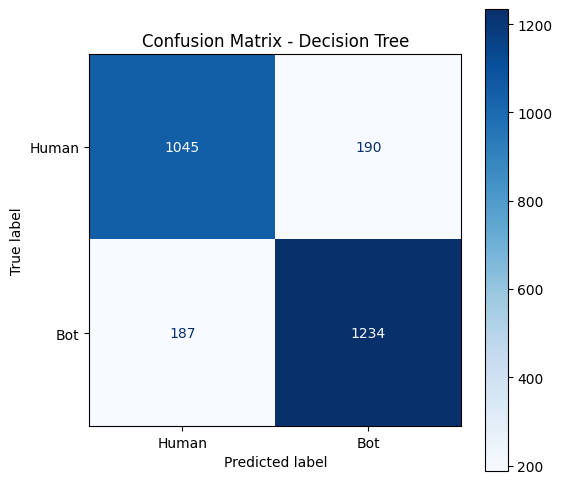

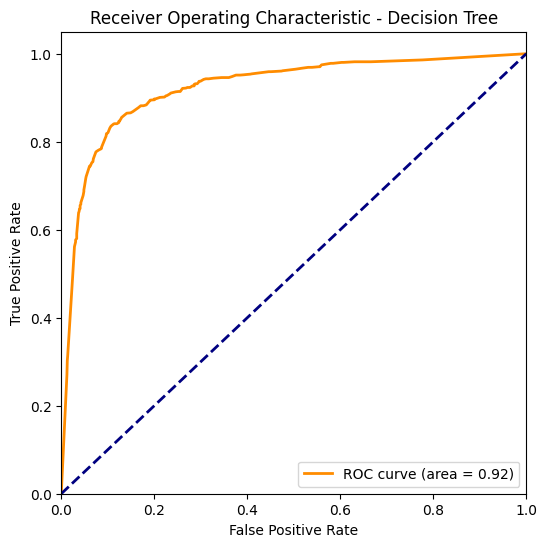

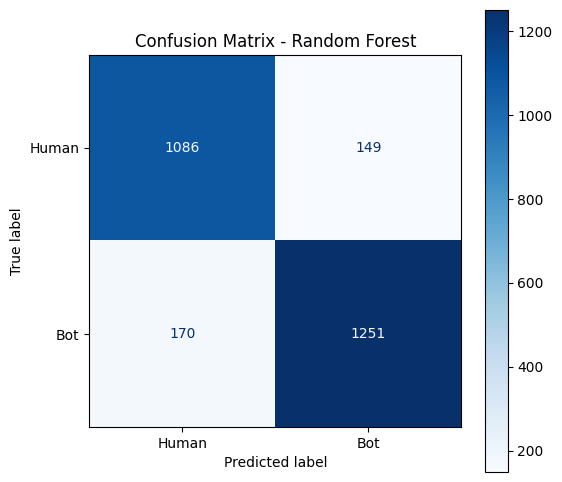

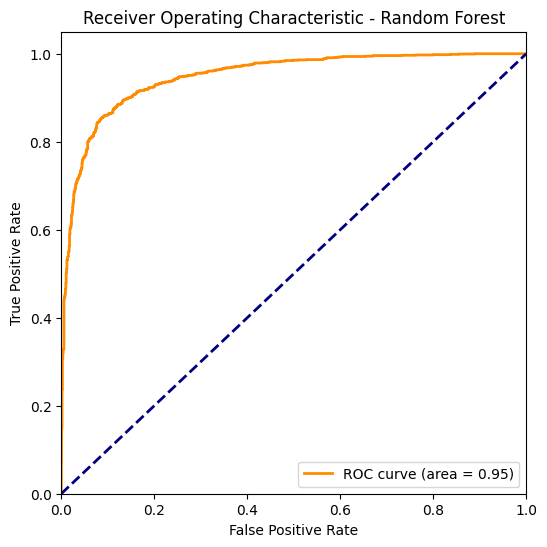

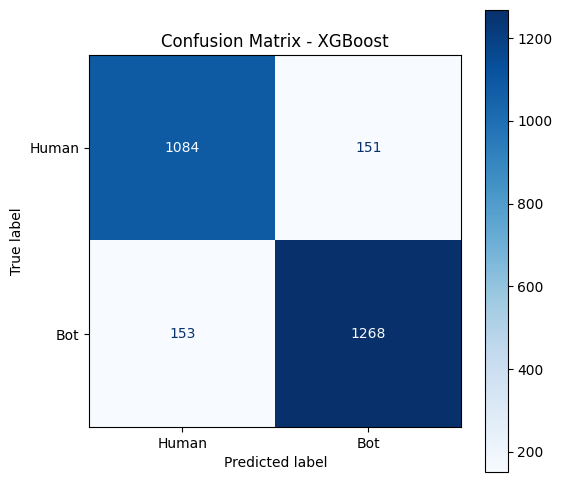

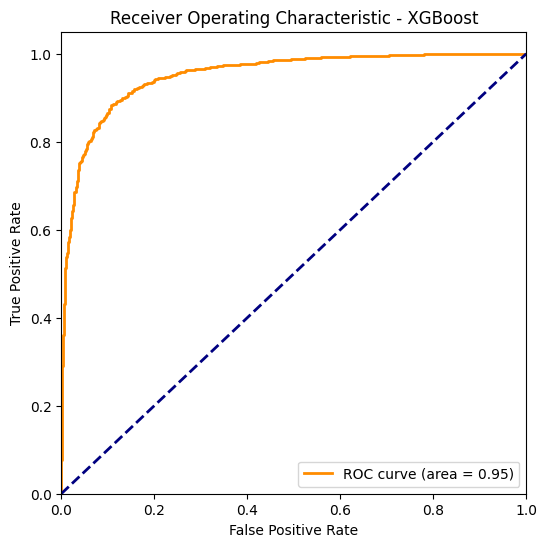

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'Bot'])
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    plt.show()

    # ROC Curve
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic - {name}')
    plt.legend(loc="lower right")
    plt.show()

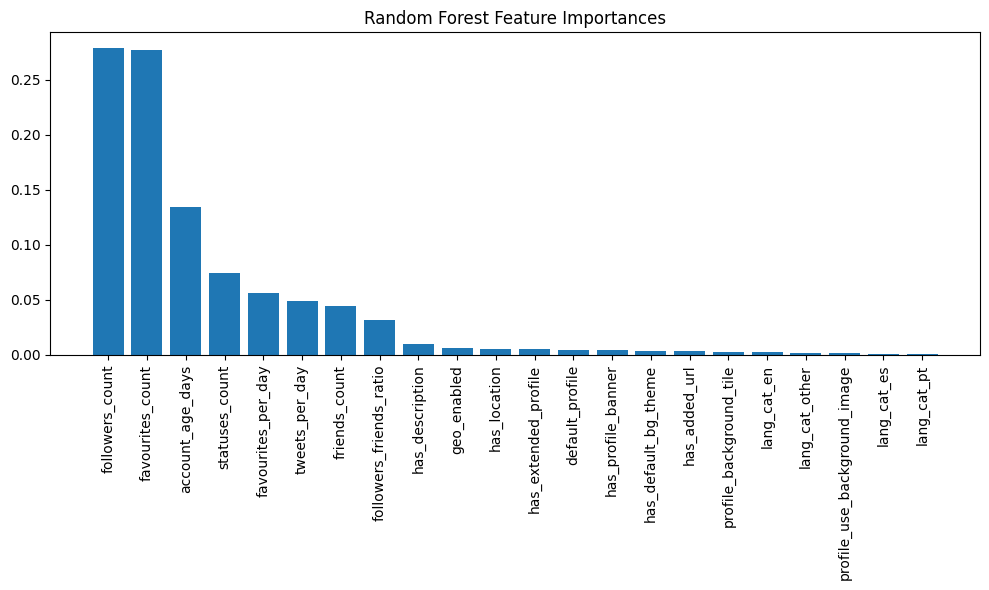

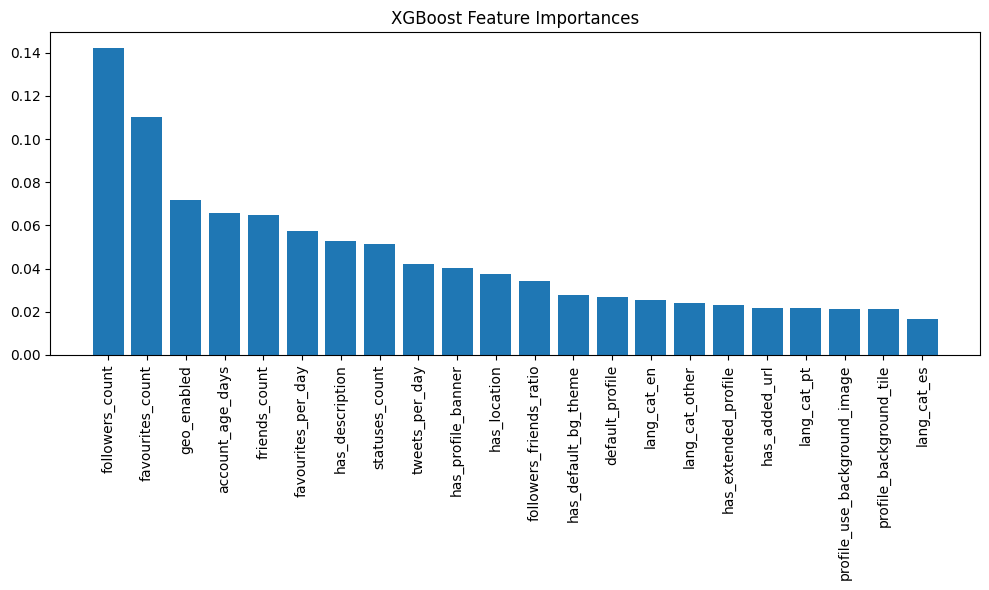

In [25]:
def plot_feature_importance(model, feature_names, title):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 6))
        plt.title(title)
        plt.bar(range(len(importances)), importances[indices], align='center')
        plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Model {title} does not have feature importances.")


# Get feature names after OHE
final_feature_names = X_train.columns

plot_feature_importance(best_models['Random Forest'], final_feature_names, 'Random Forest Feature Importances')
plot_feature_importance(best_models['XGBoost'], final_feature_names, 'XGBoost Feature Importances')

In [28]:
def get_feature_importance(model, feature_names):
    importances = model.feature_importances_

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    feature_importance_df = feature_importance_df.sort_values(
        by='Importance',
        ascending=False
    )

    return feature_importance_df


rf_importance = get_feature_importance(
    best_models['Random Forest'],
    final_feature_names
)

xgb_importance = get_feature_importance(
    best_models['XGBoost'],
    final_feature_names
)

print("Random Forest:")
display(rf_importance)

print("XGBoost:")
display(xgb_importance)

Random Forest:


,Feature,Importance
0,followers_count,0.278909
2,favourites_count,0.276822
14,account_age_days,0.134528
4,statuses_count,0.074069
17,favourites_per_day,0.056155
16,tweets_per_day,0.049228
1,friends_count,0.044068
15,followers_friends_ratio,0.031258
9,has_description,0.009950
3,geo_enabled,0.006457


XGBoost:


,Feature,Importance
0,followers_count,0.142330
2,favourites_count,0.110022
3,geo_enabled,0.071983
14,account_age_days,0.065671
1,friends_count,0.064674
17,favourites_per_day,0.057490
9,has_description,0.052986
4,statuses_count,0.051316
16,tweets_per_day,0.041925
13,has_profile_banner,0.040394


In [ ]:
import pkg_resources
import sys

with open('requirements.txt', 'w') as f:
    for package in installed_packages:
        f.write(package + '\n')


requirements.txt generated successfully!


/tmp/ipykernel_2031/4166051493.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
